# About Datasets

link  https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000

From Authors
Training of neural networks for automated diagnosis of pigmented skin lesions is hampered by the small size and lack of diversity of available dataset of dermatoscopic images. We tackle this problem by releasing the HAM10000 ("Human Against Machine with 10000 training images") dataset. We collected dermatoscopic images from different populations, acquired and stored by different modalities. The final dataset consists of 10015 dermatoscopic images which can serve as a training set for academic machine learning purposes. Cases include a representative collection of all important diagnostic categories in the realm of pigmented lesions: Actinic keratoses and intraepithelial carcinoma / Bowen's disease (akiec), basal cell carcinoma (bcc), benign keratosis-like lesions (solar lentigines / seborrheic keratoses and lichen-planus like keratoses, bkl), dermatofibroma (df), melanoma (mel), melanocytic nevi (nv) and vascular lesions (angiomas, angiokeratomas, pyogenic granulomas and hemorrhage, vasc).

More than 50% of lesions are confirmed through histopathology (histo), the ground truth for the rest of the cases is either follow-up examination (follow_up), expert consensus (consensus), or confirmation by in-vivo confocal microscopy (confocal). The dataset includes lesions with multiple images, which can be tracked by the lesion_id-column within the HAM10000_metadata file.

The test set is not public, but the evaluation server remains running (see the challenge website). Any publications written using the HAM10000 data should be evaluated on the official test set hosted there, so that methods can be fairly compared.

## Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report

2025-10-03 13:39:03.329492: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759498743.521310      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759498743.569053      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Load The Data

In [4]:
df = pd.read_csv('../input/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv')

In [5]:
df

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel0775,pixel0776,pixel0777,pixel0778,pixel0779,pixel0780,pixel0781,pixel0782,pixel0783,label
0,169,171,170,177,181,182,181,185,194,192,...,184,186,185,180,157,140,140,159,165,2
1,19,57,105,140,149,148,144,155,170,170,...,172,175,160,144,114,89,47,18,18,2
2,155,163,161,167,167,172,155,152,165,175,...,163,178,157,166,167,148,141,136,115,2
3,25,71,116,139,136,153,148,161,172,162,...,125,135,138,137,111,71,32,16,16,2
4,129,162,181,196,205,208,205,213,225,224,...,210,197,172,190,195,193,181,147,88,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,172,171,173,175,164,187,207,210,208,206,...,210,217,221,209,185,187,192,192,192,0
10011,2,34,108,116,114,119,131,139,139,145,...,173,169,168,168,143,138,83,23,3,0
10012,122,154,162,170,179,197,200,195,202,199,...,221,215,205,187,209,198,187,164,156,0
10013,137,143,141,139,147,152,155,152,155,159,...,172,171,175,183,177,170,169,166,170,0


## Exploring the data

In [9]:
df.isnull().sum().sum()

0

In [10]:
df.duplicated().sum()

2

## Preprocessing

In [13]:
X = data.drop('label', axis=1).copy()
y = data['label'].copy()

In [15]:
X

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel0774,pixel0775,pixel0776,pixel0777,pixel0778,pixel0779,pixel0780,pixel0781,pixel0782,pixel0783
0,169,171,170,177,181,182,181,185,194,192,...,176,184,186,185,180,157,140,140,159,165
1,19,57,105,140,149,148,144,155,170,170,...,181,172,175,160,144,114,89,47,18,18
2,155,163,161,167,167,172,155,152,165,175,...,162,163,178,157,166,167,148,141,136,115
3,25,71,116,139,136,153,148,161,172,162,...,142,125,135,138,137,111,71,32,16,16
4,129,162,181,196,205,208,205,213,225,224,...,211,210,197,172,190,195,193,181,147,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,172,171,173,175,164,187,207,210,208,206,...,210,210,217,221,209,185,187,192,192,192
10011,2,34,108,116,114,119,131,139,139,145,...,184,173,169,168,168,143,138,83,23,3
10012,122,154,162,170,179,197,200,195,202,199,...,223,221,215,205,187,209,198,187,164,156
10013,137,143,141,139,147,152,155,152,155,159,...,178,172,171,175,183,177,170,169,166,170


In [19]:
label_mapping = {
    0: 'nv',
    1: 'mel',
    2: 'bkl',
    3: 'bcc',
    4: 'akiec',
    5: 'vasc',
    6: 'df'
}

In [20]:
X = X / 255

X

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel0774,pixel0775,pixel0776,pixel0777,pixel0778,pixel0779,pixel0780,pixel0781,pixel0782,pixel0783
0,0.662745,0.670588,0.666667,0.694118,0.709804,0.713725,0.709804,0.725490,0.760784,0.752941,...,0.690196,0.721569,0.729412,0.725490,0.705882,0.615686,0.549020,0.549020,0.623529,0.647059
1,0.074510,0.223529,0.411765,0.549020,0.584314,0.580392,0.564706,0.607843,0.666667,0.666667,...,0.709804,0.674510,0.686275,0.627451,0.564706,0.447059,0.349020,0.184314,0.070588,0.070588
2,0.607843,0.639216,0.631373,0.654902,0.654902,0.674510,0.607843,0.596078,0.647059,0.686275,...,0.635294,0.639216,0.698039,0.615686,0.650980,0.654902,0.580392,0.552941,0.533333,0.450980
3,0.098039,0.278431,0.454902,0.545098,0.533333,0.600000,0.580392,0.631373,0.674510,0.635294,...,0.556863,0.490196,0.529412,0.541176,0.537255,0.435294,0.278431,0.125490,0.062745,0.062745
4,0.505882,0.635294,0.709804,0.768627,0.803922,0.815686,0.803922,0.835294,0.882353,0.878431,...,0.827451,0.823529,0.772549,0.674510,0.745098,0.764706,0.756863,0.709804,0.576471,0.345098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,0.674510,0.670588,0.678431,0.686275,0.643137,0.733333,0.811765,0.823529,0.815686,0.807843,...,0.823529,0.823529,0.850980,0.866667,0.819608,0.725490,0.733333,0.752941,0.752941,0.752941
10011,0.007843,0.133333,0.423529,0.454902,0.447059,0.466667,0.513725,0.545098,0.545098,0.568627,...,0.721569,0.678431,0.662745,0.658824,0.658824,0.560784,0.541176,0.325490,0.090196,0.011765
10012,0.478431,0.603922,0.635294,0.666667,0.701961,0.772549,0.784314,0.764706,0.792157,0.780392,...,0.874510,0.866667,0.843137,0.803922,0.733333,0.819608,0.776471,0.733333,0.643137,0.611765
10013,0.537255,0.560784,0.552941,0.545098,0.576471,0.596078,0.607843,0.596078,0.607843,0.623529,...,0.698039,0.674510,0.670588,0.686275,0.717647,0.694118,0.666667,0.662745,0.650980,0.666667


In [21]:
X = np.array(X)
print(X.shape)

(10015, 784)


In [22]:
X = X.reshape(-1, 28, 28, 1)
print(X.shape)

(10015, 28, 28, 1)


## Train test split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=123)

## Model

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool1 (MaxPooling2D)         │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2 (MaxPooling2D)         │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool3 (MaxPooling2D)         │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool                         │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,751 (92.78 KB)

 Trainable params: 23,751 (92.78 KB)

 Non-trainable params: 0 (0.00 B)

None


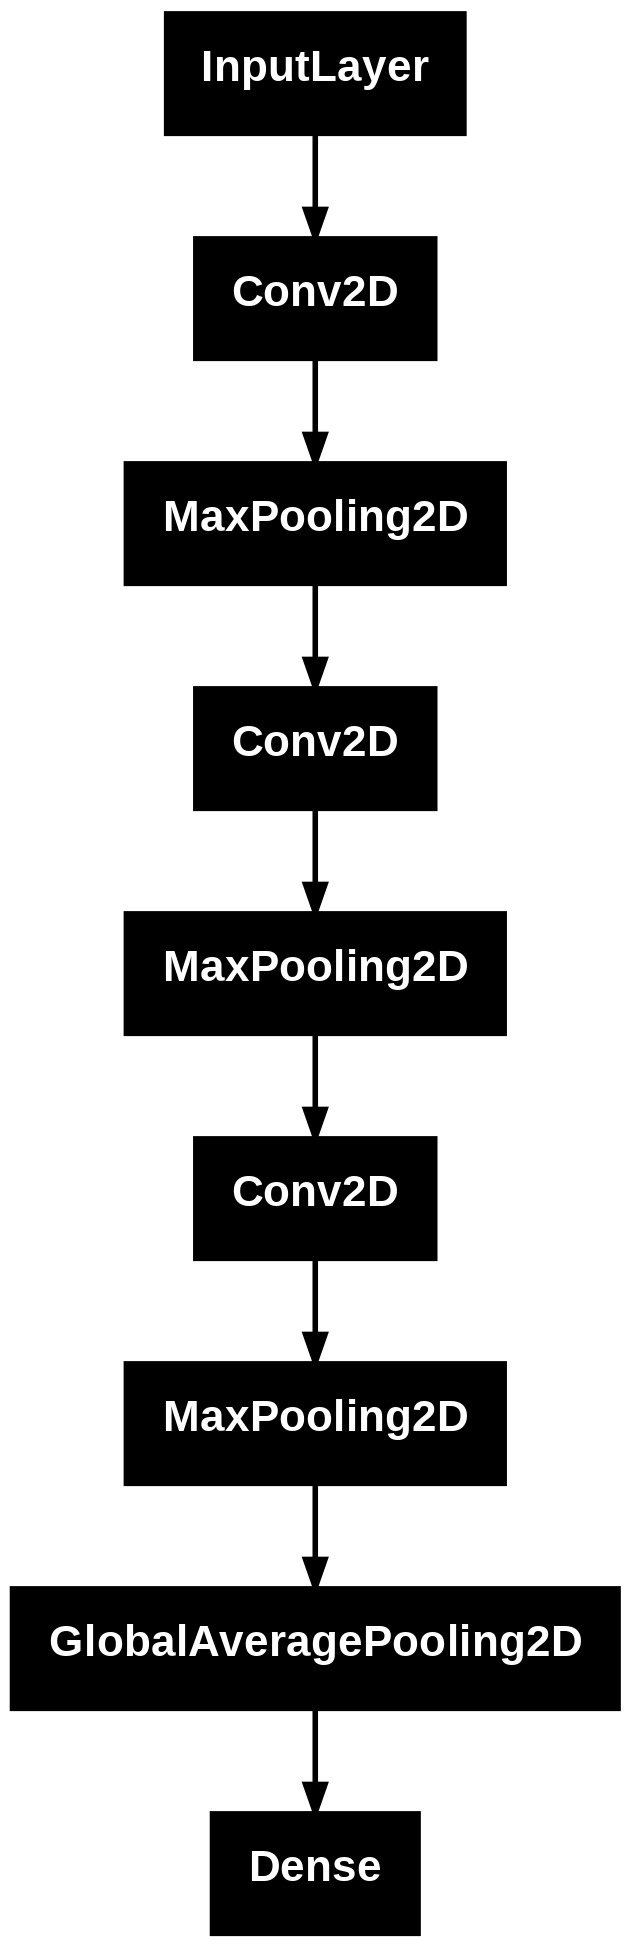

In [44]:
inputs = tf.keras.Input(shape=(28, 28, 1), name='input')

conv1 = tf.keras.layers.Conv2D(filters=16, kernel_size=3, name='conv1')(inputs)
maxpool1 = tf.keras.layers.MaxPooling2D(name='maxpool1')(conv1)

conv2 = tf.keras.layers.Conv2D(filters=32, kernel_size=3, name='conv2')(maxpool1)
maxpool2 = tf.keras.layers.MaxPooling2D(name='maxpool2')(conv2)

conv3 = tf.keras.layers.Conv2D(filters=64, kernel_size=3, name='conv3')(maxpool2)
maxpool3 = tf.keras.layers.MaxPooling2D(name='maxpool3')(conv3)


avgpool = tf.keras.layers.GlobalAveragePooling2D(name='avgpool')(maxpool3)

outputs = tf.keras.layers.Dense(7, activation='softmax', name='output')(avgpool)


model = tf.keras.Model(inputs=inputs, outputs=outputs)

print(model.summary())
tf.keras.utils.plot_model(model)

In [45]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


batch_size = 64
epochs = 100

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6360 - loss: 1.2736 - val_accuracy: 0.6583 - val_loss: 1.1422
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6839 - loss: 1.0824 - val_accuracy: 0.6583 - val_loss: 1.1032
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6766 - loss: 1.0384 - val_accuracy: 0.6555 - val_loss: 1.0476
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6806 - loss: 0.9757 - val_accuracy: 0.6626 - val_loss: 0.9935
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6810 - loss: 0.9459 - val_accuracy: 0.6605 - val_loss: 0.9674
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6904 - loss: 0.8991 - val_accuracy: 0.6662 - val_loss: 0.9575
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6848 - loss: 0.9148 - val_accuracy: 0.6662 - val_loss: 0.9394
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6952 - loss: 0.8963 - val_accuracy: 0.6690 - 

## Results

In [46]:
model_acc = model.evaluate(X_test, y_test, verbose=0)[1]

print("Test Accuracy: {:.3f}%".format(model_acc * 100))

Test Accuracy: 68.120%


## Complex Model

Model: "cnn_28x28_strong"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv1 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn1 (BatchNormalization)     │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_relu1 (Activation)           │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv2 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn2 (BatchNormalization)     │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_relu2 (Activation)           │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling2D)          │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_drop (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv1 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn1 (BatchNormalization)     │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_relu1 (Activation)           │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv2 (Conv2D)               │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn2 (BatchNormalization)     │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_relu2 (Activation)           │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_drop (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv1 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn1 (BatchNormalization)     │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_relu1 (Activation)           │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv2 (Conv2D)               │ (None, 7, 7, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn2 (BatchNormalization)     │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_relu2 (Activation)           │ (None, 7, 7, 128)      │             

 Total params: 305,191 (1.16 MB)

 Trainable params: 304,295 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

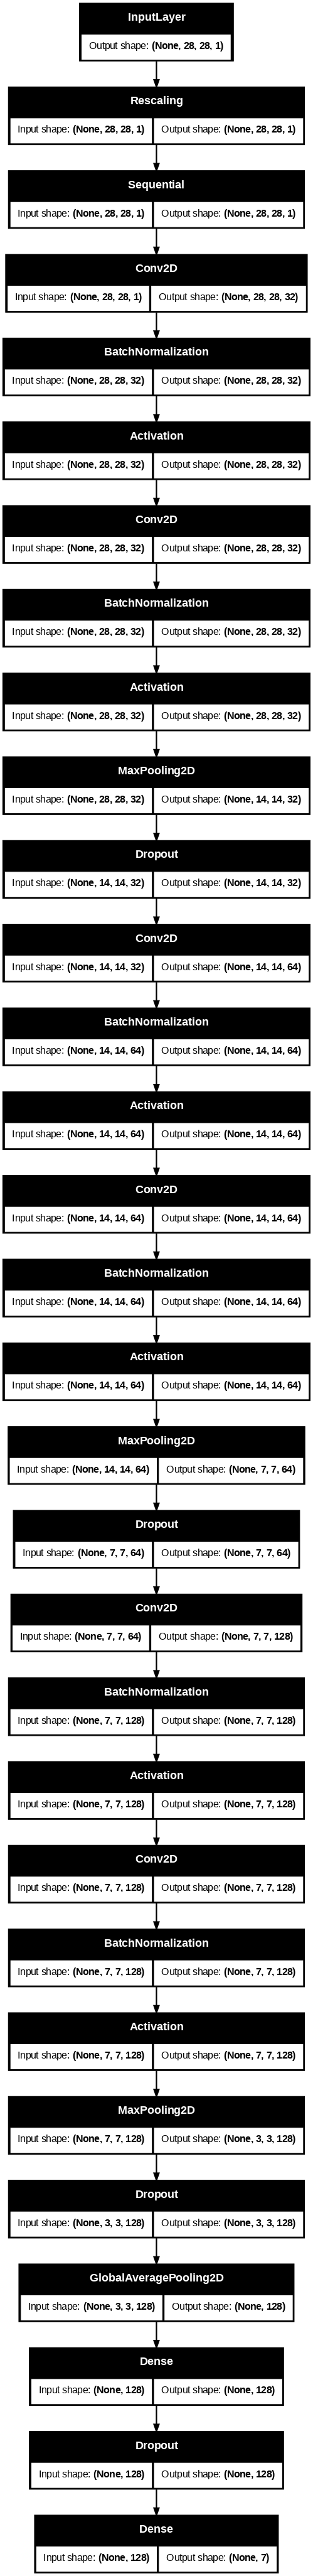

In [54]:
import tensorflow as tf

NUM_CLASSES = 7
INPUT_SHAPE = (28, 28, 1)

# small, effective augmentation (still OK without val set)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="augment")

def conv_block(x, filters, drop=0.0, name="blk"):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv1")(x)
    x = tf.keras.layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = tf.keras.layers.Activation("relu", name=f"{name}_relu1")(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv2")(x)
    x = tf.keras.layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = tf.keras.layers.Activation("relu", name=f"{name}_relu2")(x)

    x = tf.keras.layers.MaxPooling2D(name=f"{name}_pool")(x)
    if drop > 0:
        x = tf.keras.layers.Dropout(drop, name=f"{name}_drop")(x)
    return x

def build_model():
    inputs = tf.keras.Input(shape=INPUT_SHAPE, name="input")
    x = tf.keras.layers.Rescaling(1./255)(inputs)
    x = augment(x)

    x = conv_block(x, 32, drop=0.15, name="b1")
    x = conv_block(x, 64, drop=0.25, name="b2")
    x = conv_block(x, 128, drop=0.35, name="b3")

    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="output")(x)

    model = tf.keras.Model(inputs, outputs, name="cnn_28x28_strong")

    # If your labels are ONE-HOT, use CategoricalCrossentropy (no 'from_logits')
    # loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

    # Integer labels (0..6)
    loss = tf.keras.losses.SparseCategoricalCrossentropy()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-3),
        loss=loss,
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2")
        ]
    )
    return model

model = build_model()
model.summary()
tf.keras.utils.plot_model(model, show_shapes=True, dpi=80)


In [55]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

callbacks = [
    # saves best weights by **training accuracy**
    ModelCheckpoint("best_train_acc.h5", monitor="acc", mode="max", save_best_only=True, verbose=1),
    # lower LR when **training loss** plateaus (since no val)
    ReduceLROnPlateau(monitor="loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1),
    # stop if **training accuracy** stops improving for a while
    EarlyStopping(monitor="acc", mode="max", patience=8, restore_best_weights=True, verbose=1),
    CSVLogger("training_log.csv", append=False),
]

history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=128,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/60


E0000 00:00:1759500311.492623      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cnn_28x28_strong_1/b1_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.6266 - loss: 1.2611 - top2: 0.7753
Epoch 1: acc improved from -inf to 0.65592, saving model to best_train_acc.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - acc: 0.6271 - loss: 1.2587 - top2: 0.7759 - learning_rate: 0.0030
Epoch 2/60
53/55 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.6574 - loss: 1.0041 - top2: 0.8218
Epoch 2: acc improved from 0.65592 to 0.67817, saving model to best_train_acc.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.6585 - loss: 1.0019 - top2: 0.8224 - learning_rate: 0.0030
Epoch 3/60
52/55 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.6870 - loss: 0.9356 - top2: 0.8301
Epoch 3: acc improved from 0.67817 to 0.69016, saving model to best_train_acc.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.6872 - loss: 0.9354 - top2: 0.8303 - learning_rate: 0.0030
Epoch 4/60
52/55 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.7008 - loss: 0.8850 - top2: 0.8376
Epoch 4: acc improved from 0.69016 to 0.69429, saving model to bes

NameError: name 'x_train' is not defined

## Results

In [57]:
final_loss, final_acc, final_top2 = model.evaluate(X_train, y_train, verbose=0)
print(f"Final Train Accuracy: {final_acc:.4f} | Top-2: {final_top2:.4f}")


Final Train Accuracy: 0.6061 | Top-2: 0.7619


## little cyhange in model

In [59]:
import tensorflow as tf
import numpy as np

NUM_CLASSES = 7
INPUT_SHAPE = (28, 28, 1)

# --- very light aug (keep it mild to maximize train acc) ---
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=42),
], name="augment")

def conv_block(x, filters, name, drop=0.0):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_c1")(x)
    x = tf.keras.layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = tf.keras.layers.Activation("gelu", name=f"{name}_gelu1")(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_c2")(x)
    x = tf.keras.layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = tf.keras.layers.Activation("gelu", name=f"{name}_gelu2")(x)

    x = tf.keras.layers.MaxPooling2D(name=f"{name}_pool")(x)
    if drop > 0:
        x = tf.keras.layers.Dropout(drop, name=f"{name}_drop")(x)
    return x

def build_model():
    inp = tf.keras.Input(shape=INPUT_SHAPE, name="input")
    x = tf.keras.layers.Rescaling(1./255, name="rescale")(inp)
    x = augment(x)

    # wider than before
    x = conv_block(x, 48, name="b1", drop=0.05)
    x = conv_block(x, 96, name="b2", drop=0.10)
    x = conv_block(x, 192, name="b3", drop=0.15)

    # FLATTEN HEAD (more params -> higher train acc)
    x = tf.keras.layers.Flatten(name="flat")(x)
    x = tf.keras.layers.Dense(256, activation="gelu", name="fc1")(x)
    x = tf.keras.layers.Dropout(0.25, name="fc1_drop")(x)
    x = tf.keras.layers.Dense(128, activation="gelu", name="fc2")(x)
    x = tf.keras.layers.Dropout(0.20, name="fc2_drop")(x)
    out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="out")(x)

    model = tf.keras.Model(inp, out, name="cnn_28x28_trainacc")

    # sparse loss (integer labels)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=tf.keras.optimizers.schedules.CosineDecayRestarts(
                initial_learning_rate=3e-3, first_decay_steps=200, t_mul=2.0, m_mul=0.8, alpha=1e-5
            )
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2"),
        ],
    )
    return model

model = build_model()
model.summary()


Model: "cnn_28x28_trainacc"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c1 (Conv2D)                  │ (None, 28, 28, 48)     │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn1 (BatchNormalization)     │ (None, 28, 28, 48)     │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_gelu1 (Activation)           │ (None, 28, 28, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c2 (Conv2D)                  │ (None, 28, 28, 48)     │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn2 (BatchNormalization)     │ (None, 28, 28, 48)     │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_gelu2 (Activation)           │ (None, 28, 28, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling2D)          │ (None, 14, 14, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_drop (Dropout)               │ (None, 14, 14, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c1 (Conv2D)                  │ (None, 14, 14, 96)     │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn1 (BatchNormalization)     │ (None, 14, 14, 96)     │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_gelu1 (Activation)           │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c2 (Conv2D)                  │ (None, 14, 14, 96)     │        82,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn2 (BatchNormalization)     │ (None, 14, 14, 96)     │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_gelu2 (Activation)           │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling2D)          │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_drop (Dropout)               │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c1 (Conv2D)                  │ (None, 7, 7, 192)      │       165,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn1 (BatchNormalization)     │ (None, 7, 7, 192)      │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_gelu1 (Activation)           │ (None, 7, 7, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c2 (Conv2D)                  │ (None, 7, 7, 192)      │       331,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn2 (BatchNormalization)     │ (None, 7, 7, 192)      │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_gelu2 (Activation)           │ (None, 7, 7, 192)      │             

 Total params: 1,122,359 (4.28 MB)

 Trainable params: 1,121,015 (4.28 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [62]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger

callbacks = [
    ModelCheckpoint(
        filepath="best_by_train_acc.h5",   # full model file
        monitor="acc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,           # <-- store full model
        verbose=1
    )
]

history = model.fit(
    X_train, y_train.astype("int32"),
    epochs=120,                # longer; cosine schedule helps
    batch_size=128,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/120
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - acc: 0.5674 - loss: 1.9501 - top2: 0.7206
Epoch 1: acc improved from -inf to 0.62825, saving model to best_by_train_acc.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - acc: 0.5685 - loss: 1.9404 - top2: 0.7217
Epoch 2/120
51/55 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.6669 - loss: 1.0814 - top2: 0.8220
Epoch 2: acc improved from 0.62825 to 0.67104, saving model to best_by_train_acc.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.6673 - loss: 1.0796 - top2: 0.8220
Epoch 3/120
53/55 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.6757 - loss: 1.0382 - top2: 0.8228
Epoch 3: acc improved from 0.67104 to 0.67447, saving model to best_by_train_acc.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.6756 - loss: 1.0377 - top2: 0.8231
Epoch 4/120
52/55 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.6736 - loss: 1.0187 - top2: 0.8357
Epoch 4: acc improved from 0.67447 to 0.67603, saving model to best_by_train_acc.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 1

## Final Results

In [63]:
final_loss, final_acc, final_top2 = model.evaluate(X_train, y_train, verbose=0)
print(f"Final Train Accuracy: {final_acc:.4f} | Top-2: {final_top2:.4f}")


Final Train Accuracy: 0.8124 | Top-2: 0.9270


Looks good n:)